In [65]:
%matplotlib inline

import numpy as np
from roboticstoolbox.robot.ERobot import ERobot
from matplotlib import pyplot
from roboticstoolbox import DHRobot, RevoluteDH, RevoluteMDH
from spatialmath import SE3

<p align="center">
    <img src="./src/robot_description/image.png" alt="robot">
</p>

ERobot: ROBOT, 3 joints (RRR), geometry
┌──────┬───────────────┬───────┬────────┬───────────────────────────────────────────┐
│ link │     link      │ joint │ parent │            ETS: parent to link            │
├──────┼───────────────┼───────┼────────┼───────────────────────────────────────────┤
│    0 │ link_0        │       │ BASE   │ SE3()                                     │
│    1 │ link_1        │     0 │ link_0 │ SE3(0, 0, 0.2) ⊕ Rz(q0)                   │
│    2 │ link_2        │     1 │ link_1 │ SE3(0, -0.12, 0; 0°, -90°, -90°) ⊕ Rz(q1) │
│    3 │ link_3        │     2 │ link_2 │ SE3(0.25, 0, 0.1) ⊕ Rz(q2)                │
│    4 │ @end_effector │       │ link_3 │ SE3(0.28, 0, 0; 90°, -0°, 90°)            │
└──────┴───────────────┴───────┴────────┴───────────────────────────────────────────┘

┌──────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2  │
├──────┼─────┼─────┼─────┤
│   qz │  0° │  0° │  0° │
└──────┴─────┴─────┴─────┘


Forward kinematics at zero configuration:
   1  

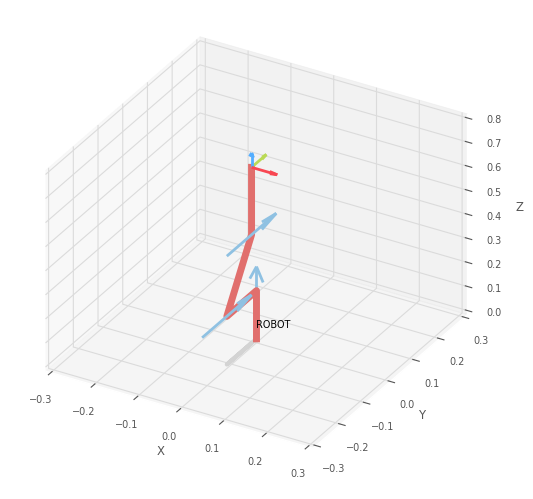

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [66]:
class MyRobot(ERobot):
    def __init__(self):
        links, name, urdf_string, urdf_filepath = self.URDF_read(
            "/home/peeradon/FRA502_LAB_6703/src/robot_description/urdf/my-robot.xacro"
        )
        super().__init__(
            links,
            name=name.upper(),
            manufacturer="",
            urdf_string=urdf_string,
            urdf_filepath=urdf_filepath,
        )

        self.qz = np.zeros(self.n)
        self.addconfiguration("qz", self.qz)

robot = MyRobot()
print(robot)
print("\nForward kinematics at zero configuration:")
print(robot.fkine(robot.qz))

robot.plot([0,0,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])


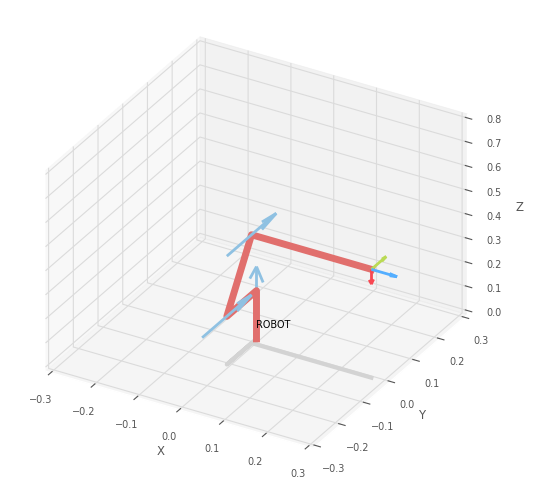

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [67]:
# tesing move joints at joint 3 at -90 degree
robot.plot([0,0,np.pi/2], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

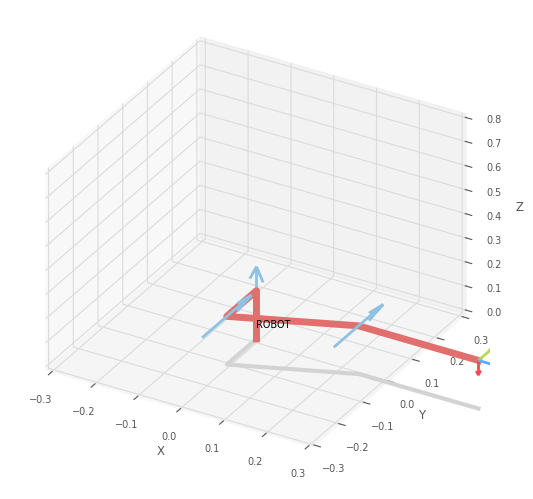

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [68]:
# tesing move joints at joint 2 at -90 degree
robot.plot([0,np.pi/2,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])